In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('../data/raw_stock_data.csv', header=[0,1], index_col=0, parse_dates=True)
close_prices = data['Close']
daily_returns = close_prices.pct_change().dropna()

print(close_prices.shape)
print(daily_returns.shape)

(1844, 8)
(1843, 8)


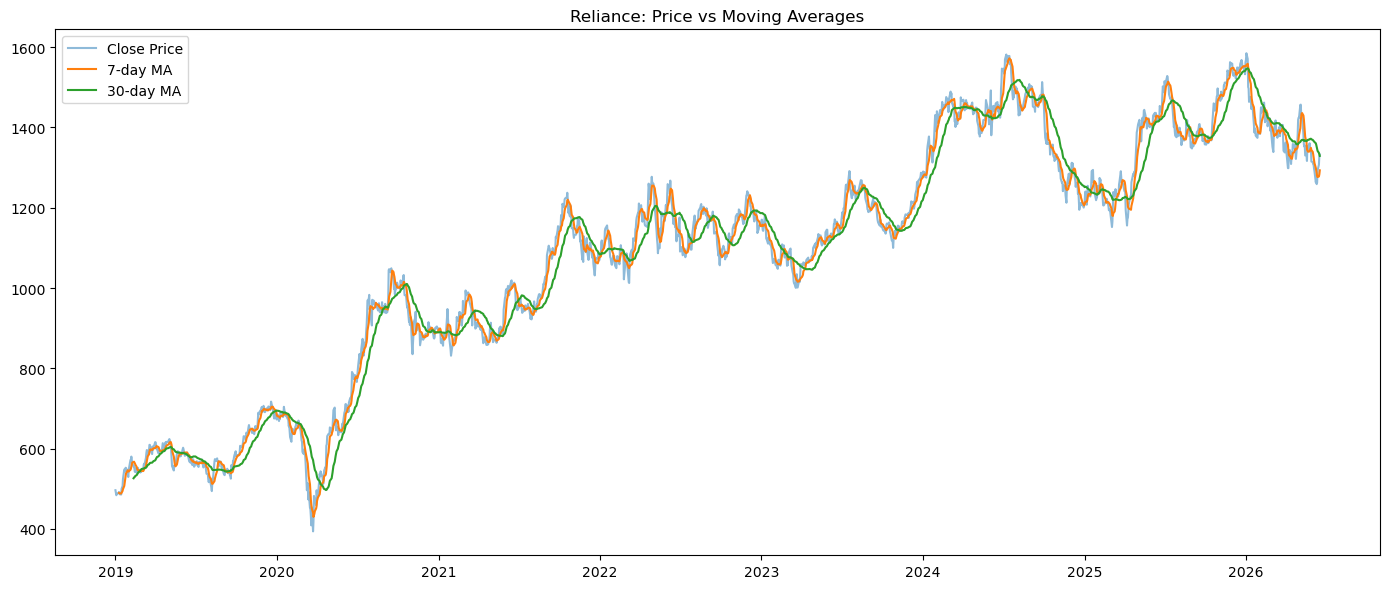

In [2]:
ma_7 = close_prices.rolling(window=7).mean()
ma_30 = close_prices.rolling(window=30).mean()

# Quick visual check on one stock
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(close_prices.index, close_prices['RELIANCE.NS'], label='Close Price', alpha=0.5)
plt.plot(ma_7.index, ma_7['RELIANCE.NS'], label='7-day MA')
plt.plot(ma_30.index, ma_30['RELIANCE.NS'], label='30-day MA')
plt.title('Reliance: Price vs Moving Averages')
plt.legend()
plt.tight_layout()
plt.show()

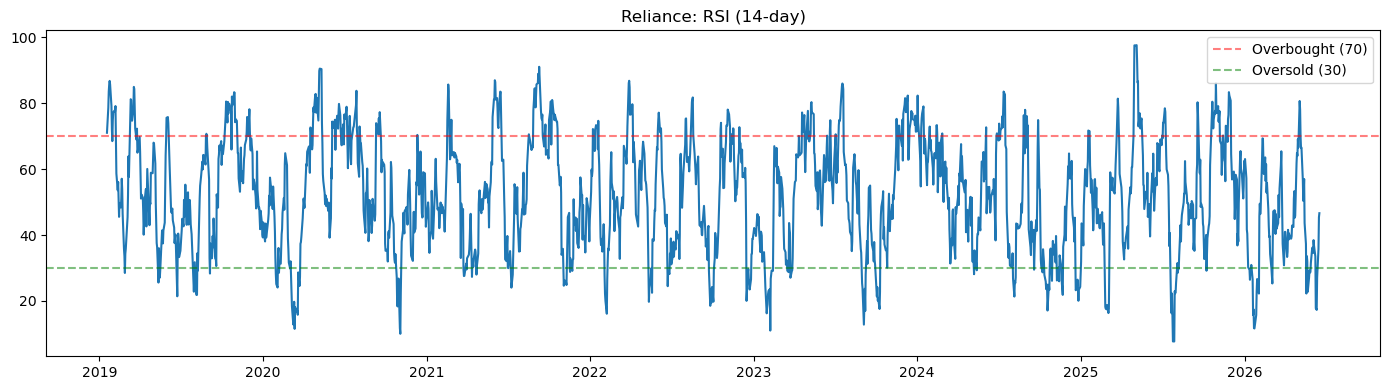

In [3]:
def calculate_rsi(prices, window=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

rsi = close_prices.apply(calculate_rsi)

plt.figure(figsize=(14, 4))
plt.plot(rsi.index, rsi['RELIANCE.NS'])
plt.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
plt.title('Reliance: RSI (14-day)')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
def build_features(ticker, close_prices, daily_returns):
    df = pd.DataFrame(index=close_prices.index)
    df['close'] = close_prices[ticker]
    df['daily_return'] = daily_returns[ticker]
    df['ma_7'] = close_prices[ticker].rolling(7).mean()
    df['ma_30'] = close_prices[ticker].rolling(30).mean()
    df['volatility_30'] = daily_returns[ticker].rolling(30).std()
    df['rsi_14'] = calculate_rsi(close_prices[ticker])
    df = df.dropna()
    return df

# Test on one stock first
reliance_features = build_features('RELIANCE.NS', close_prices, daily_returns)
print(reliance_features.head())
print(reliance_features.shape)

                 close  daily_return        ma_7       ma_30  volatility_30  \
Date                                                                          
2019-02-12  556.129517      0.002514  567.236503  527.929060       0.017475   
2019-02-14  541.876526     -0.025629  563.018790  529.667148       0.018040   
2019-02-15  550.839966      0.016541  560.040475  531.905416       0.017934   
2019-02-18  540.061707     -0.019567  554.339957  533.697357       0.018462   
2019-02-19  538.291260     -0.003278  549.641689  535.340281       0.018501   

               rsi_14  
Date                   
2019-02-12  56.078330  
2019-02-14  45.505477  
2019-02-15  49.720691  
2019-02-18  48.344114  
2019-02-19  51.007624  
(1814, 6)


In [5]:
tickers = close_prices.columns.tolist()
all_features = {}

for ticker in tickers:
    all_features[ticker] = build_features(ticker, close_prices, daily_returns)

# Quick check - confirm all 8 are built
for ticker in tickers:
    print(ticker, all_features[ticker].shape)

BHARTIARTL.NS (1814, 6)
HDFCBANK.NS (1814, 6)
HINDUNILVR.NS (1814, 6)
ICICIBANK.NS (1814, 6)
INFY.NS (1814, 6)
RELIANCE.NS (1814, 6)
TCS.NS (1814, 6)
TMPV.NS (1814, 6)


In [6]:
import os
os.makedirs('../data/features', exist_ok=True)

for ticker in tickers:
    filename = ticker.replace('.NS', '') + '_features.csv'
    all_features[ticker].to_csv(f'../data/features/{filename}')

print(os.listdir('../data/features'))

['BHARTIARTL_features.csv', 'HDFCBANK_features.csv', 'HINDUNILVR_features.csv', 'ICICIBANK_features.csv', 'INFY_features.csv', 'RELIANCE_features.csv', 'TCS_features.csv', 'TMPV_features.csv']
